<div style="color:#3c4d5a; border-top: 7px solid #42A5F5; border-bottom: 7px solid #42A5F5; padding: 5px; text-align: center; text-transform: uppercase"><h1> Transfer Learning Yolo 11 Segmentation</h1> </div>

Desarrollador por: Justin Lucero, Jhonatan Tacuri

Para el desarrollo de esta práctica se utilizó el dataset disponible en Roboflow:
https://universe.roboflow.com/yanelys/clothing-segmentation-dataset/dataset/9
.
Dicho conjunto de datos fue descargado y empleado posteriormente para realizar el proceso de transfer learning.

El dataset está compuesto por imágenes de prendas de vestir y contiene las siguientes categorías: coat, dress, jacket, pants, shirt, shorts, skirt y t-shirt.

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="tWmqkF6yQmOs5jydLkRb")
project = rf.workspace("yanelys").project("clothing-segmentation-dataset")
version = project.version(9)
dataset = version.download("yolov11")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Clothing-Segmentation-DataSet-9 in yolov11:: 100%|██████████| 2180/2180 [00:00<00:00, 23743.09it/s]


## Transfer Learning

Para esta práctica se utilizó el modelo YOLOv11 Nano Segmentation, el cual fue empleado para realizar el proceso de transfer learning utilizando el dataset descargado previamente.

El entrenamiento se llevó a cabo durante 200 épocas, con un tamaño de batch de 16, con el objetivo de ajustar el modelo a las características específicas del conjunto de datos de prendas de vestir.

Si deseas que lo haga más técnico, más corto o más descriptivo (por ejemplo, mencionando hardware o métricas), dime y lo adapto.

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n-seg.pt")

model.train(
    data="/home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/Clothing-Segmentation-DataSet-9/data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    device=0   
)


Ultralytics 8.3.250 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7816MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/Clothing-Segmentation-DataSet-9/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train17, nbs=64, nms=False, opset=N

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x72017161fc20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0

In [2]:
model = YOLO("/home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/runs/segment/train17/weights/best.pt")

model.predict(
    source="/home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/Clothing-Detection-3/test/images",
    save=True,
    conf=0.4
)


image 1/10 /home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/Clothing-Detection-3/test/images/e506b0eb1993de080270c957c9ea4087_jpg.rf.1fd4414c796e290ab514bd4dfaf4d6fb.jpg: 448x640 1 t-shirt, 37.0ms
image 2/10 /home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/Clothing-Detection-3/test/images/image_Backpack_16_jpg.rf.d2ae9b0fdc7889c1929610121cd063eb.jpg: 448x640 1 shirt, 1 t-shirt, 3.4ms
image 3/10 /home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/Clothing-Detection-3/test/images/image_Backpack_23_jpg.rf.d9042216df9298d1357c1808ea585268.jpg: 640x640 1 shorts, 1 t-shirt, 3.7ms
image 4/10 /home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/Clothing-Detection-3/test/images/image_Beanies_12_jpg.rf.d87dc96a5a17a0eeae531cafefba59c8.jpg: 448x640 (no detections), 3.6ms
image 5/10 /home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/Clothing-Detection-3/test/images/image_Beanies_9_jpg.rf.22ae551140bba7118858fce26325cc69.jpg: 448x64

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'coat', 1: 'dress', 2: 'jacket', 3: 'pants', 4: 'shirt', 5: 'shorts', 6: 'skirt', 7: 't-shirt'}
 obb: None
 orig_img: array([[[116, 131, 194],
         [135, 150, 212],
         [144, 159, 221],
         ...,
         [157, 174, 201],
         [156, 173, 199],
         [160, 177, 203]],
 
        [[136, 151, 214],
         [141, 156, 218],
         [139, 154, 216],
         ...,
         [161, 176, 208],
         [156, 171, 203],
         [157, 173, 202]],
 
        [[147, 162, 225],
         [138, 153, 215],
         [127, 142, 204],
         ...,
         [163, 175, 217],
         [159, 171, 213],
         [159, 171, 211]],
 
        ...,
 
        [[ 21,  27,  68],
         [  8,  14,  55],
         [ 13,  19,  60],
         ...,
         [131, 142, 186],
         [132, 144, 186],
         [139, 151

Se realizaron pruebas utilizando el conjunto de test incluido en el propio dataset, con el fin de evaluar el desempeño del modelo entrenado.

A continuación, se presentan algunos de los resultados obtenidos durante dichas pruebas.


0: 448x640 (no detections), 6.0ms
Speed: 2.1ms preprocess, 6.0ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)

0: 640x448 1 shirt, 1 t-shirt, 33.3ms
Speed: 1.6ms preprocess, 33.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 448)

0: 640x480 1 jacket, 3.8ms
Speed: 1.6ms preprocess, 3.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)


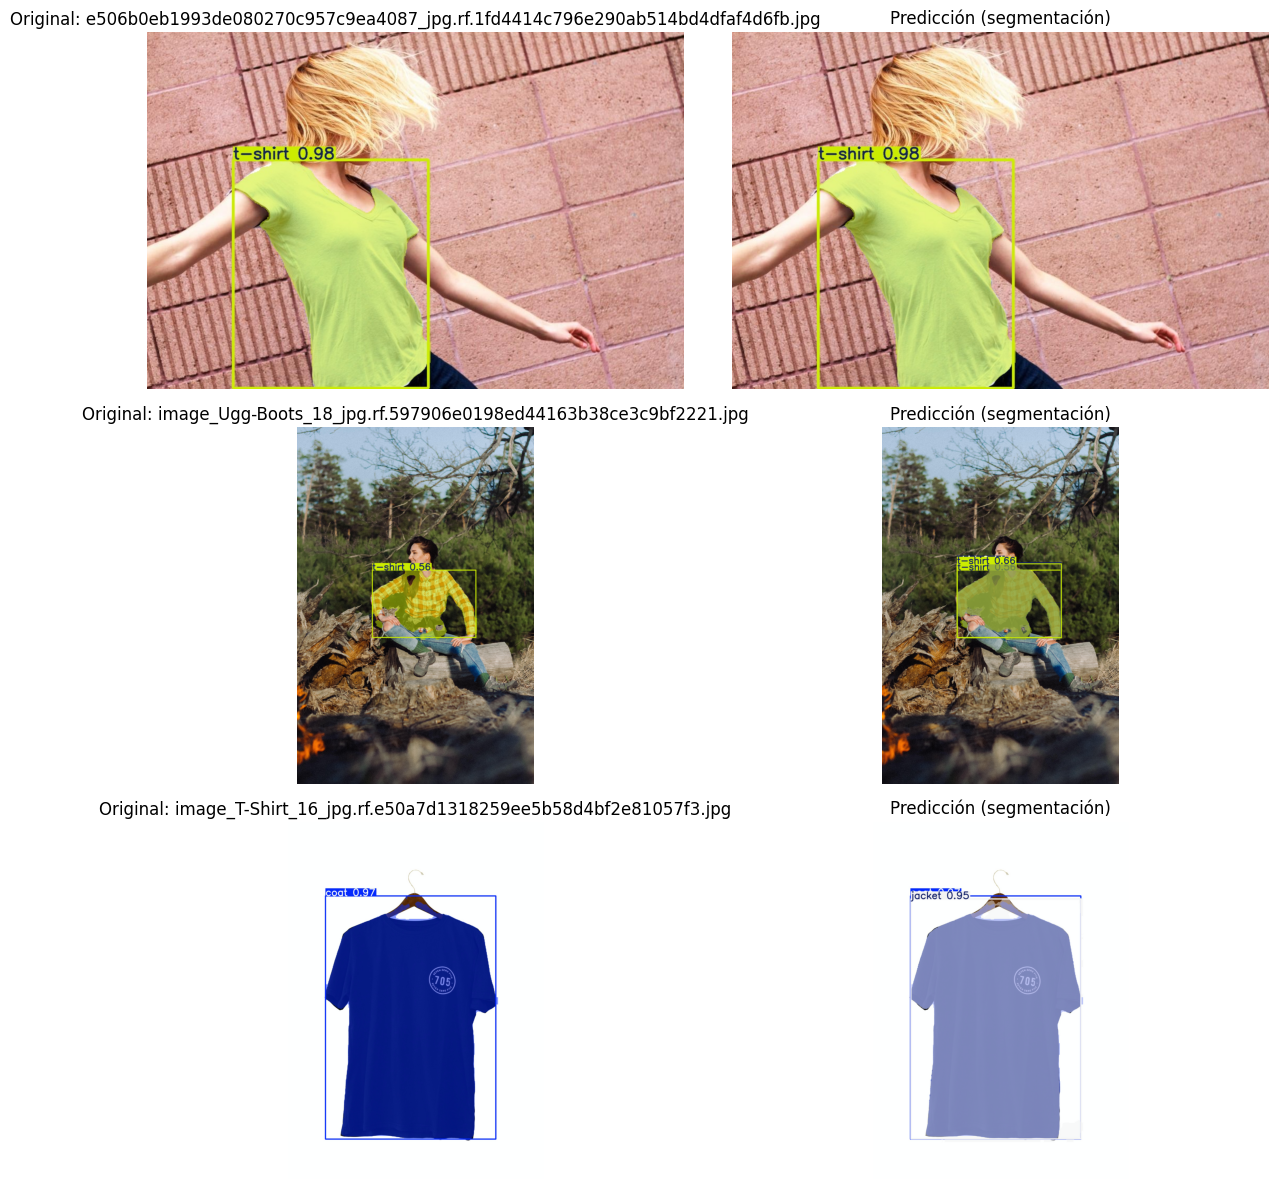

In [5]:
import cv2
import glob
import os
import random

import matplotlib.pyplot as plt

TEST_DIR = "/home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/runs/segment/predict7"

files = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    files.extend(glob.glob(os.path.join(TEST_DIR, ext)))
if not files:
    raise FileNotFoundError(f"No se encontraron imágenes en {TEST_DIR}")

sample = random.sample(files, min(3, len(files)))

fig, axes = plt.subplots(nrows=len(sample), ncols=2, figsize=(12, 4 * len(sample)))
if len(sample) == 1:
    axes = [axes] 
for i, fp in enumerate(sample):
    img = cv2.imread(fp)  
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model(img, conf=0.4)  
    overlay = results[0].plot()
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    ax_orig, ax_pred = axes[i]
    ax_orig.imshow(img_rgb)
    ax_orig.set_title(f"Original: {os.path.basename(fp)}")
    ax_orig.axis("off")

    ax_pred.imshow(overlay_rgb)
    ax_pred.set_title("Predicción (segmentación)")
    ax_pred.axis("off")

plt.tight_layout()
plt.show()

In [6]:
from ultralytics import YOLO
import cv2

model = YOLO("/home/justin/Documentos/VISION/Practica-Unidad-4-Vision/PARTE1A/runs/segment/train17/weights/best.pt")

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, conf=0.4)
    frame = results[0].plot()

    cv2.imshow("YOLOv11 Segmentation", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



0: 480x640 1 shirt, 13.3ms
Speed: 2.6ms preprocess, 13.3ms inference, 2.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 coat, 1 shirt, 12.2ms
Speed: 2.0ms preprocess, 12.2ms inference, 2.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 coat, 1 shirt, 11.0ms
Speed: 2.3ms preprocess, 11.0ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 coat, 1 shirt, 8.7ms
Speed: 2.1ms preprocess, 8.7ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 coat, 1 shirt, 8.6ms
Speed: 1.7ms preprocess, 8.6ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 coat, 1 shirt, 12.0ms
Speed: 2.0ms preprocess, 12.0ms inference, 2.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 coat, 1 shirt, 12.0ms
Speed: 2.3ms preprocess, 12.0ms inference, 2.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 coat, 1 shirt, 12.3ms
Speed: 2.4ms preprocess, 12.3ms inference, 2.

Se realizaron pruebas utilizando la webcam, con el objetivo de evaluar el modelo en tiempo real.

A continuación, se muestra el funcionamiento del sistema de detección y segmentación durante la ejecución.
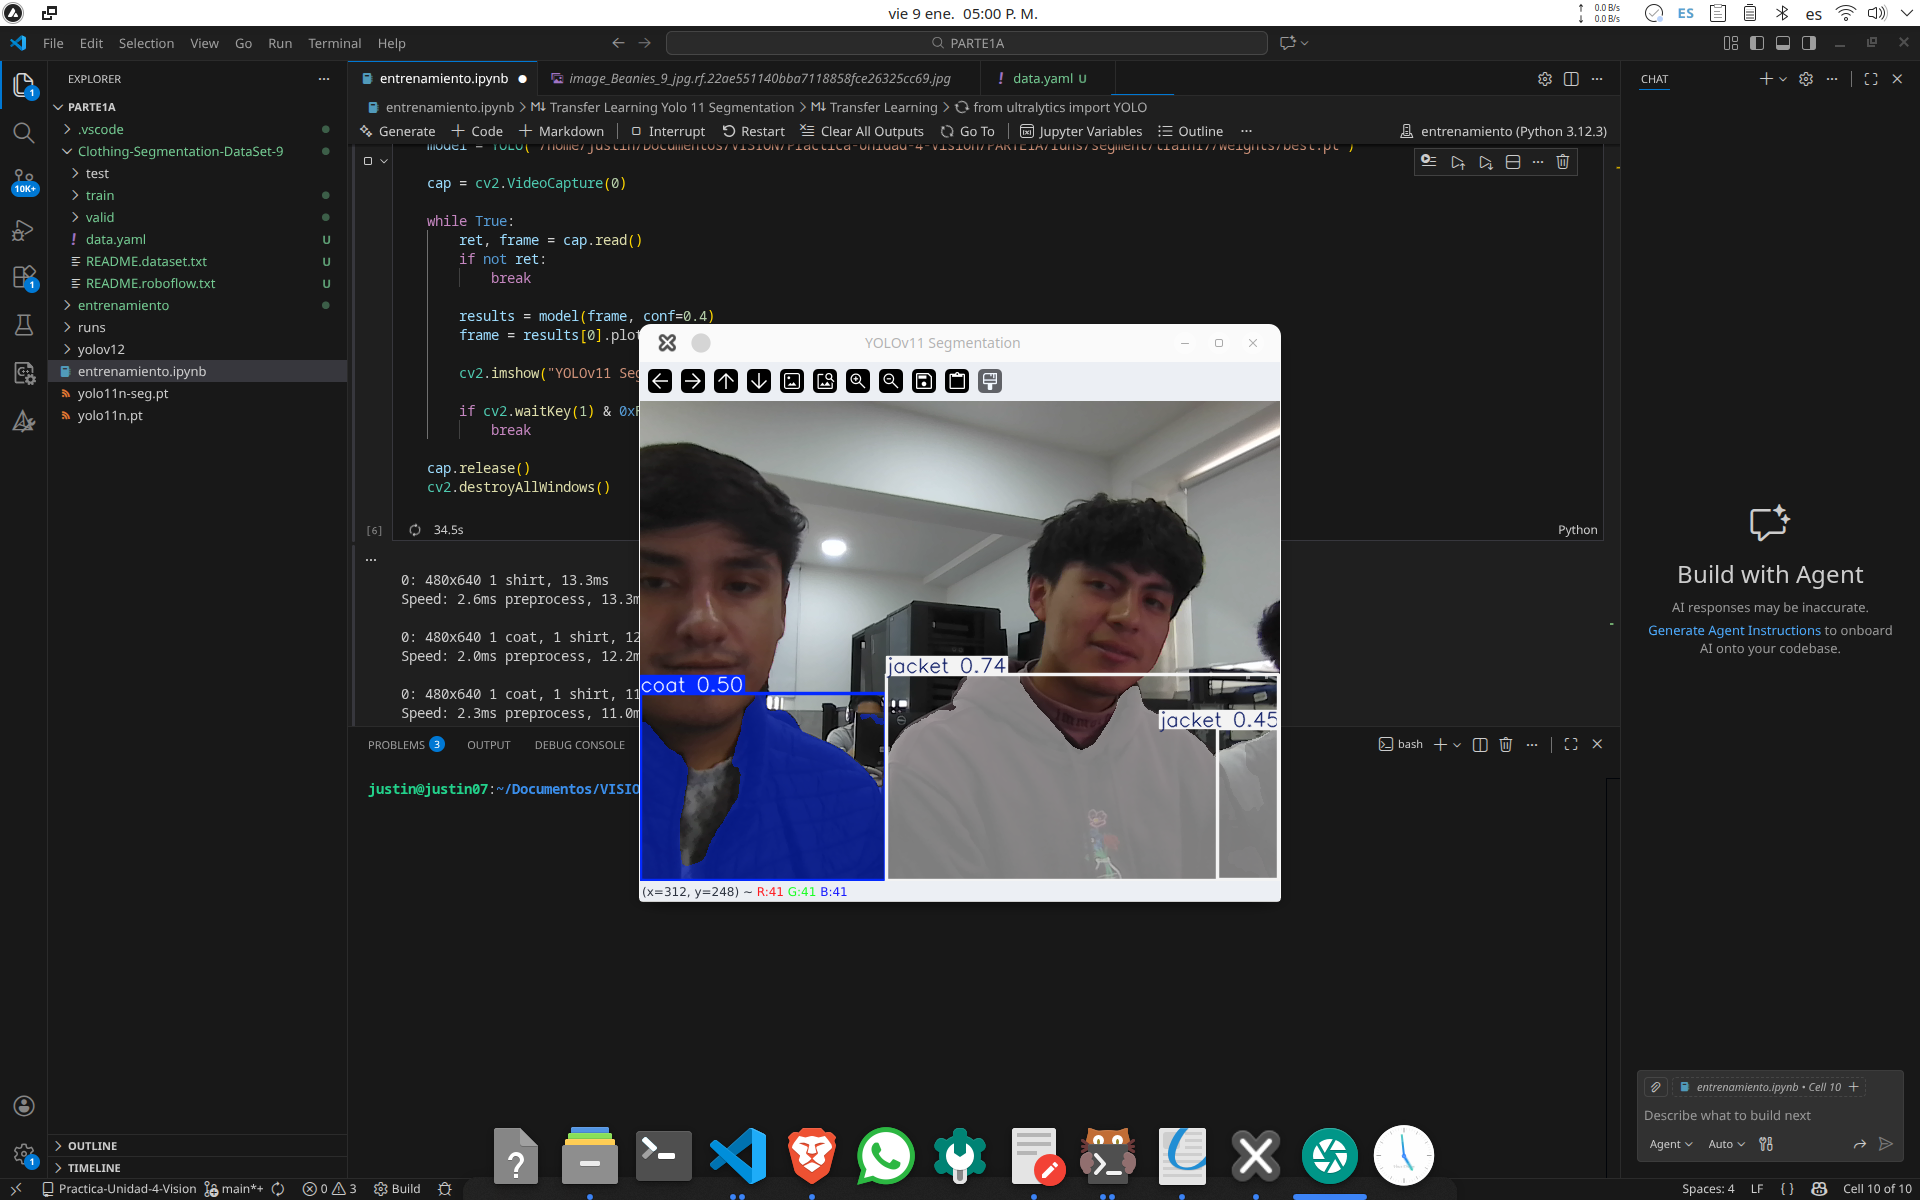

<div id="preparacion-datos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Conclusiones</h2> </div>

El uso de transfer learning con el modelo YOLOv11 Nano Segmentation permitió obtener resultados satisfactorios en la segmentación de prendas de vestir, reduciendo significativamente el tiempo de entrenamiento en comparación con un entrenamiento desde cero.

El modelo demostró un buen desempeño al identificar y segmentar correctamente las diferentes categorías de ropa presentes en el dataset, tanto en las pruebas realizadas con el conjunto de test como en las evaluaciones en tiempo real mediante la webcam.

La implementación de un tamaño de batch de 16 y un total de 200 épocas permitió lograr un equilibrio adecuado entre precisión y estabilidad durante el proceso de entrenamiento.

Con las pruebas con la webcam se logra verificar que el modelo es capaz de funcionar de manera eficiente en escenarios prácticos, manteniendo una detección fluida y consistente.

<div id="preparacion-datos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Referencias</h2> </div>

Roboflow. (2023). Clothing segmentation dataset. Roboflow Universe. https://universe.roboflow.com/yanelys/clothing-segmentation-dataset

Panda, A., Panigrahi, D., Mitra, S., Mittal, S., & Rahimi, S. (2024). Transfer learning applied to computer vision problems: Survey on current progress, limitations, and opportunities. arXiv. https://doi.org/10.48550/arXiv.2409.07736